<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/kmeans_Euclidean_Distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📐 1. Formulasi Matematis Euclidean Distance & Fungsi Objektif

### 1.1. Euclidean Distance ($L_2$ Norm)
Jarak garis lurus antara dua vektor $x, y \in \mathbb{R}^p$:
$$d_{\mathrm{Euclidean}}(x,y)=\sqrt{\sum_{i=1}^{p}(x_i-y_i)^2}.$$

### 1.2. Fungsi Objektif (Sum of Squared Errors / SSE)
K-Means meminimalkan jumlah kuadrat jarak setiap data ke centroid klasternya:
$$J=\sum_{j=1}^{K}\sum_{x\in S_j}\lVert x-\mu_j\rVert_2^2.$$
Centroid diperbarui menggunakan rata-rata anggota klaster:
$$\mu_j=\frac{1}{|S_j|}\sum_{x\in S_j}x.$$

Dataset yang digunakan adalah `dataset_B_05_2020 (1).csv`. Kolom `url` dan
`status` disimpan sebagai metadata dan label asli. Semua baris digunakan;
PCA diterapkan pada tahap visualisasi.

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

from kneed import KneeLocator


In [ ]:
# =======================================================================
# 2. DATASET & PREPROCESSING
# =======================================================================
FILE = 'dataset_B_05_2020 (1).csv'
df = pd.read_csv(FILE)

print('Shape dataset:', df.shape)
print('Jumlah data:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
display(df.head(3))

# Metadata dan label asli disimpan terpisah dari fitur clustering.
urls = df['url'].copy()
y_true = df['status'].copy()
labels = y_true.copy()
X = df.drop(columns=['url', 'status']).select_dtypes(include=np.number)
print('Shape fitur numerik:', X.shape)

# Imputasi median, penghapusan fitur konstan, lalu StandardScaler.
print('Missing value sebelum imputasi:', int(X.isna().sum().sum()))
X = X.fillna(X.median())
print('Missing value setelah imputasi:', int(X.isna().sum().sum()))

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
removed_features = X.columns[~selector.get_support()]
X_selected = pd.DataFrame(X_sel, columns=selected_features, index=X.index)
print('Fitur konstan yang dihapus:', list(removed_features))
print('Shape setelah seleksi fitur:', X_selected.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
df_after = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print('Shape setelah StandardScaler:', X_scaled.shape)
display(df_after.head(3))


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


Shape fitur numerik: (11430, 87)
Missing value sebelum imputasi: 0
Missing value setelah imputasi: 0
Fitur konstan yang dihapus: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah seleksi fitur: (11430, 81)
Shape setelah StandardScaler: (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


## 📈 2. Penentuan Jumlah Klaster (Elbow Method)

SSE dihitung untuk $k=1,\ldots,9$:
$$\mathrm{SSE}(k)=\sum_{j=1}^{k}\sum_{x\in S_j}\lVert x-\mu_j\rVert_2^2.$$
Titik siku dipilih dengan `KneeLocator`. Jika titik siku tidak ditemukan,
kurva dinilai memakai jarak maksimum terhadap garis penghubung kedua ujung.
Silhouette seluruh data dihitung untuk $k=2,\ldots,9$ sebagai evaluasi tambahan.

K yang dipilih (Elbow): 4


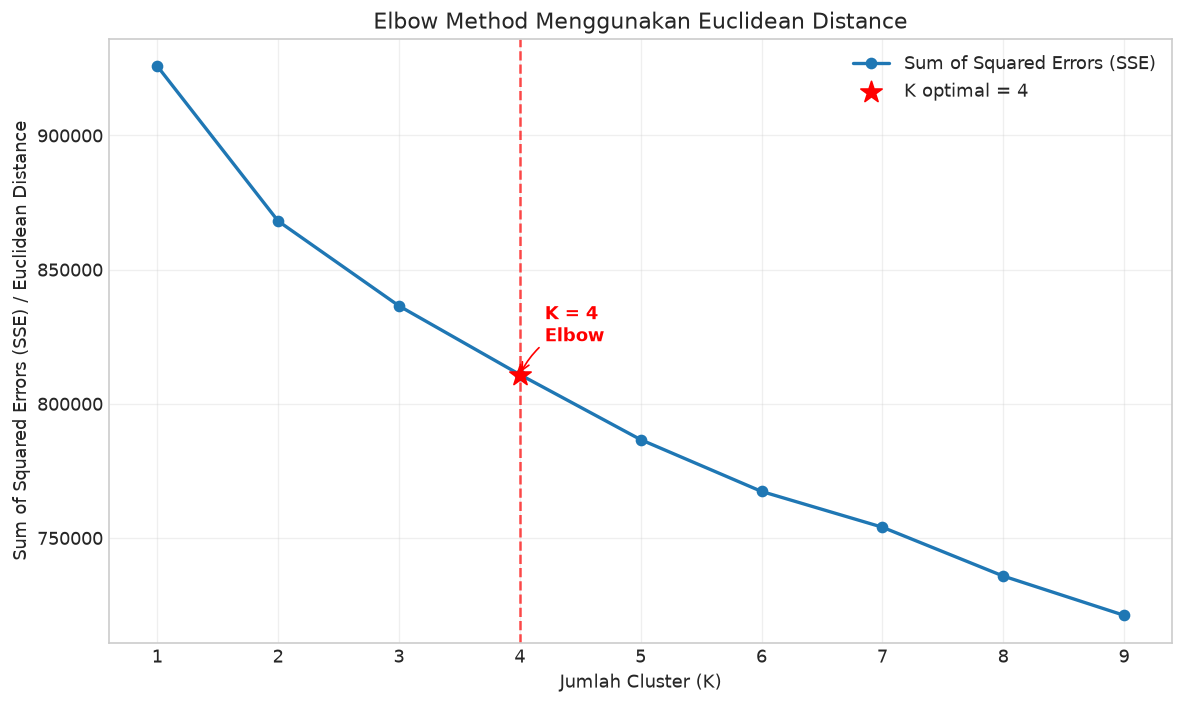

k=1; SSE=925830.0000000001
k=2; SSE=868078.5870757783
k=3; SSE=836455.302809329
k=4; SSE=810859.5471781364
k=5; SSE=786607.5986408119
k=6; SSE=767312.1744230168
k=7; SSE=753974.1107965733
k=8; SSE=735774.0449128721
k=9; SSE=721144.2111806673
Menghitung Silhouette Score...


Untuk k=2, Silhouette Score = 0.3323


Untuk k=3, Silhouette Score = 0.0648


Untuk k=4, Silhouette Score = 0.0785


Untuk k=5, Silhouette Score = 0.0611


Untuk k=6, Silhouette Score = 0.0682


Untuk k=7, Silhouette Score = 0.0726


Untuk k=8, Silhouette Score = 0.0747


Untuk k=9, Silhouette Score = 0.0387


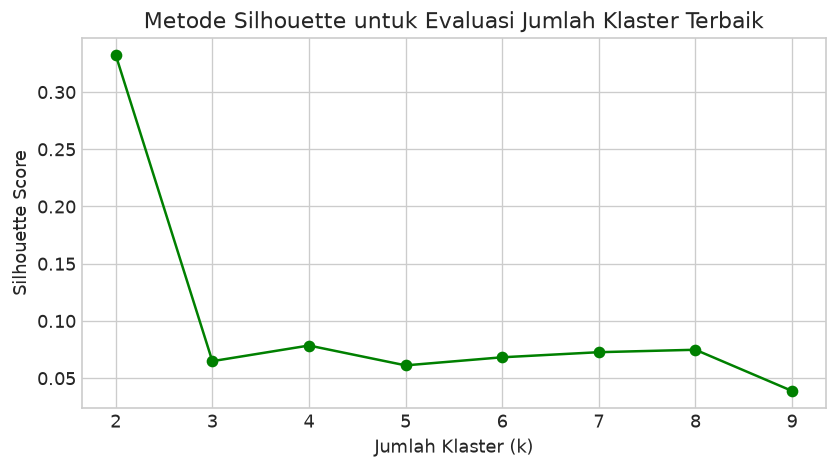

In [ ]:
# =======================================================================
# 3. ELBOW EUCLIDEAN & EVALUASI JUMLAH KLASTER
# =======================================================================
# 1. Menghitung SSE untuk K 1 hingga 9
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(X_scaled)
    sse.append(kmeanModel.inertia_)

# 2. Mencari K optimal dengan KneeLocator
kl = KneeLocator(K, sse, curve="convex", direction="decreasing")
optimal_k = kl.elbow
if optimal_k is None:
    # Jarak tegak lurus pada kurva yang dinormalisasi.
    x = np.asarray(list(K), dtype=float)
    y = np.asarray(sse, dtype=float)
    xn = (x - x.min()) / np.ptp(x)
    yn = (y - y.min()) / np.ptp(y) if np.ptp(y) > 0 else np.zeros_like(y)
    optimal_k = list(K)[int(np.argmax(np.abs(xn + yn - 1)))]
    print('KneeLocator tidak menemukan siku; digunakan estimasi geometris.')
optimal_k = int(optimal_k)
print('K yang dipilih (Elbow):', optimal_k)

# Mencari indeks dari optimal_k di dalam list K untuk mendapatkan nilai Y (SSE) yang tepat
optimal_index = list(K).index(optimal_k)

# 3. Visualisasi dengan gaya kustom
plt.figure(figsize=(10, 6))

plt.plot(
    K,
    sse,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Sum of Squared Errors (SSE)"
)

if optimal_k is not None:
    # Titik K optimal
    plt.scatter(
        optimal_k,
        sse[optimal_index],
        s=180,
        color="red",
        marker="*",
        zorder=5,
        label=f"K optimal = {optimal_k}"
    )

    # Garis vertikal
    plt.axvline(
        optimal_k,
        color="red",
        linestyle="--",
        alpha=0.7
    )

    # Label Anotasi
    plt.annotate(
        f"K = {optimal_k}\nElbow",
        xy=(
            optimal_k,
            sse[optimal_index]
        ),
        xytext=(15, 20), # Disesuaikan sedikit agar teks tidak tertabrak garis
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="red",
        arrowprops=dict(arrowstyle="->", color="red", connectionstyle="arc3,rad=.2")
    )

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE) / Euclidean Distance")
plt.title("Elbow Method Menggunakan Euclidean Distance")

plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

sil_scores = []
K_sil = range(2, 10) # Range k=2 hingga k=9

print("Menghitung Silhouette Score...")
for k in K_sil:
    # Inisialisasi dan latih model
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_sil.fit_predict(X_scaled)

    # Silhouette dihitung pada seluruh data.
    score = silhouette_score(X_scaled, labels_k)
    sil_scores.append(score)

    print(f"Untuk k={k}, Silhouette Score = {score:.4f}")

# Memvisualisasikan hasil
plt.figure(figsize=(8, 4))
plt.plot(K_sil, sil_scores, "go-")
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Metode Silhouette untuk Evaluasi Jumlah Klaster Terbaik")
plt.grid(True)
plt.show()


In [ ]:
# =======================================================================
# 4. KONFIGURASI MODEL K-MEANS EUCLIDEAN
# =======================================================================
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)


In [ ]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING & METRIK EVALUASI
# =======================================================================
kmeans.fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)
centers = kmeans.cluster_centers_
silhouette_euclidean = silhouette_score(X_scaled, y_kmeans, metric='euclidean')

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean',
    'K yang Dipilih': optimal_k,
    'Jumlah Klaster': len(np.unique(y_kmeans)),
    'Silhouette Score': silhouette_euclidean,
    'Objective Value (SSE)': kmeans.inertia_,
    'Iterations': kmeans.n_iter_,
}])
display(eval_df.round(4))
print('Jumlah data per klaster:')
display(pd.Series(y_kmeans, name='Cluster').value_counts().sort_index().to_frame('Jumlah Data'))


,Distance Metric,K yang Dipilih,Jumlah Klaster,Silhouette Score,Objective Value (SSE),Iterations
0,Euclidean,4,4,0.0785,810859.5472,26


Jumlah data per klaster:


,Jumlah Data
Cluster,
0,3932
1,6470
2,928
3,100


Total explained variance PCA: 15.51%


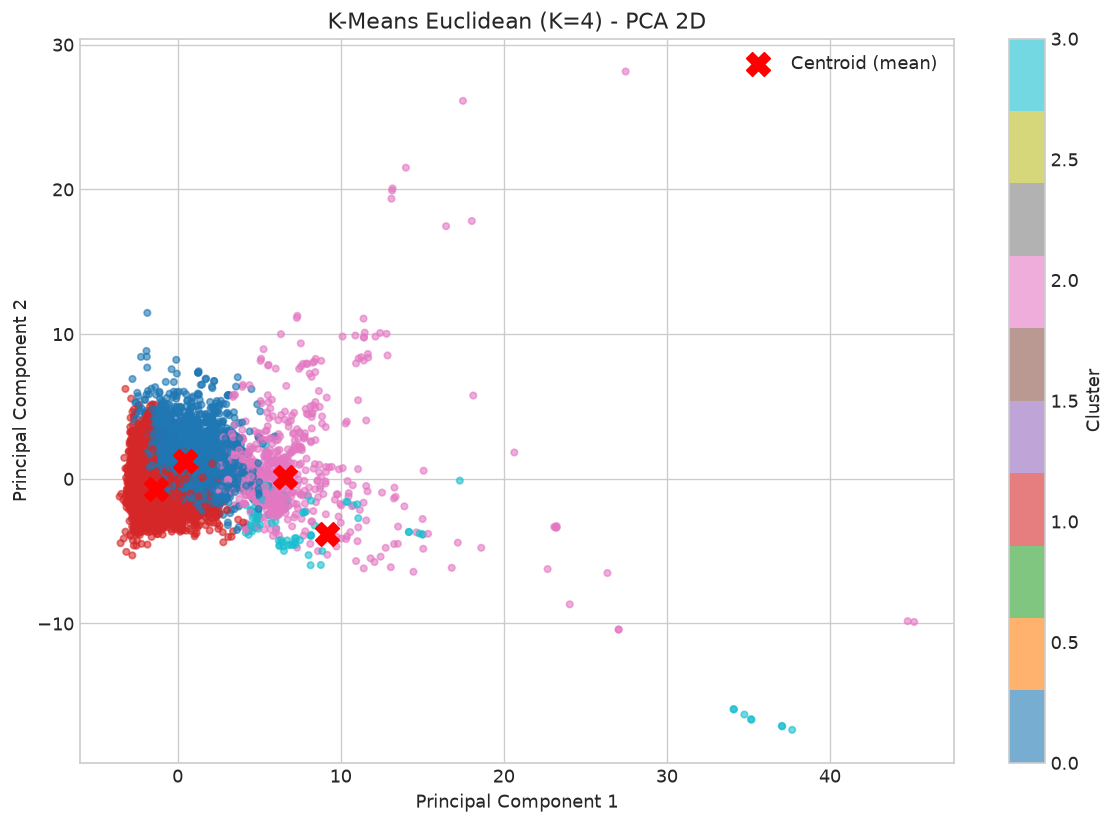

In [ ]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca = PCA(n_components=2, svd_solver='full', random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
centers_2d = pca.transform(centers)
print(f'Total explained variance PCA: {pca.explained_variance_ratio_.sum():.2%}')

plt.figure(figsize=(10, 7))
points = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_kmeans, cmap='tab10', s=15, alpha=0.6)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', marker='X', s=200, label='Centroid (mean)')
plt.colorbar(points, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Euclidean (K={optimal_k}) - PCA 2D')
plt.legend()
plt.tight_layout()
plt.show()
